# Start


In [272]:
import pandas as pd
from pathlib import Path

data_dir = next(
    path for path in (
        Path('input/titanic'),
        Path('Kaggle/input/titanic'),
        Path('../input/titanic')
    )
    if path.exists()
)

train = pd.read_csv(data_dir / 'train.csv')
test = pd.read_csv(data_dir / 'test.csv')

In [273]:
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# LoadData

In [274]:
print('Number of passengers in train dataset: ' + str(len(train)))
print('Number of passengers in test dataset: ' + str(len(test)))

Number of passengers in train dataset: 891
Number of passengers in test dataset: 418


# Data Analysis

# Number of passengers Survived

<Axes: xlabel='Survived', ylabel='count'>

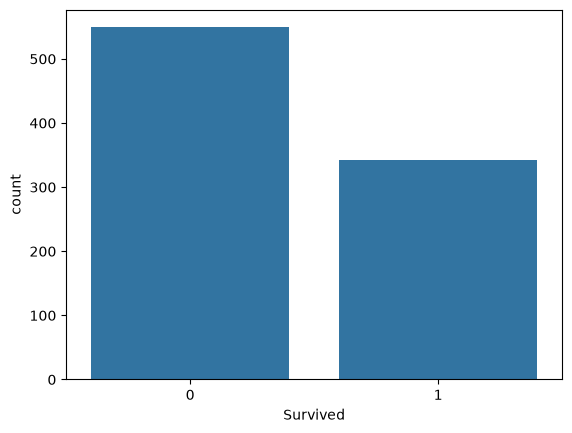

In [275]:
sns.countplot(x = 'Survived', data = train)

# Number of passengers Survived based on Passenger Class

<Axes: xlabel='Survived', ylabel='count'>

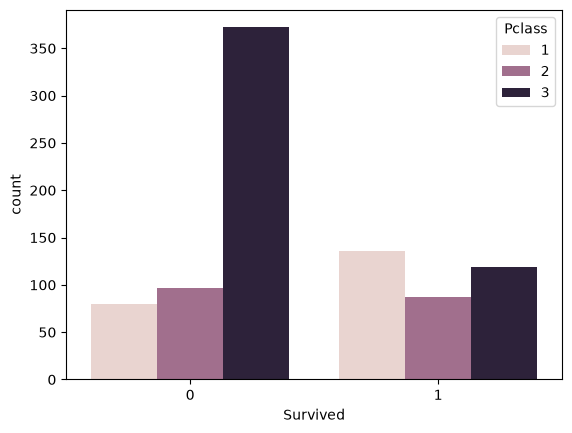

In [276]:
sns.countplot(x = 'Survived', hue = 'Pclass', data = train)

# Frequency of passengers group by Age

<Axes: ylabel='Frequency'>

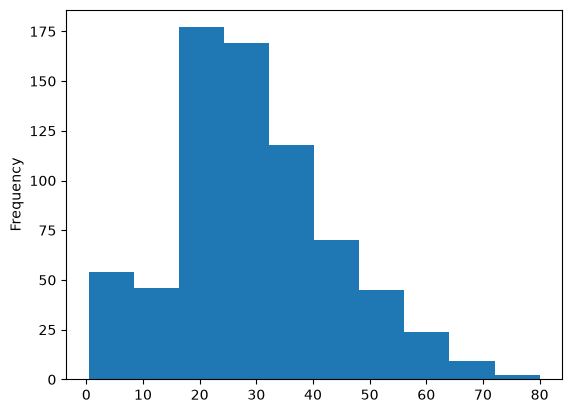

In [277]:
train['Age'].plot.hist()

# Frequency of passengers group by Fare


<Axes: ylabel='Frequency'>

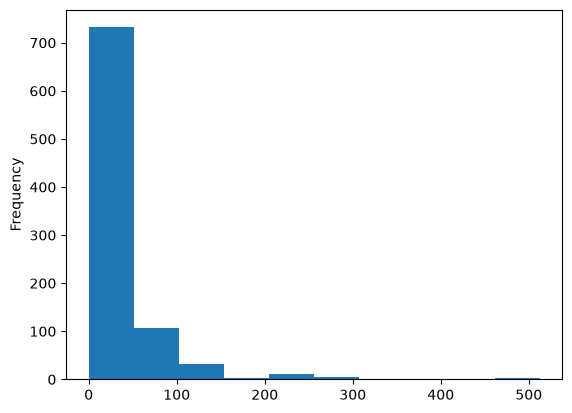

In [278]:
train['Fare'].plot.hist()

# Train Dataset Information

In [279]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# Number of siblings / spouses aboard the Titanic

<Axes: xlabel='SibSp', ylabel='count'>

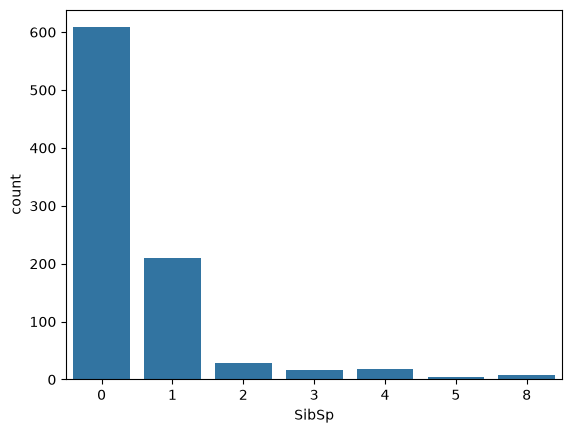

In [280]:
sns.countplot(x = 'SibSp', data = train)

# Check for NULL values in training set

In [281]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Heatmap for NULL values

<Axes: >

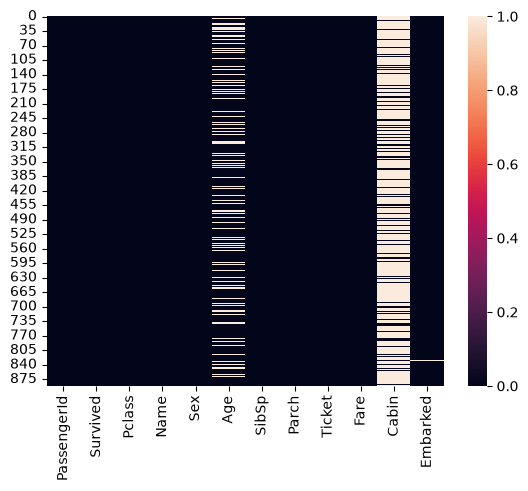

In [282]:
sns.heatmap(train.isnull())

# Passenger Class vs Age

<Axes: xlabel='Pclass', ylabel='Age'>

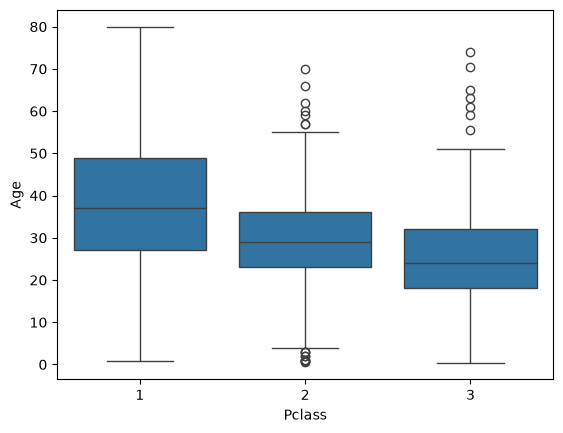

In [283]:
sns.boxplot(x = 'Pclass', y = 'Age', data = train)

# Data Preprocessing

# Train Data

In [284]:
sex = pd.get_dummies(train['Sex'], drop_first = True)
embark = pd.get_dummies(train['Embarked'],drop_first=True)
pcl = pd.get_dummies(train['Pclass'],drop_first=True)

# Concat new features in train data

In [285]:
train = pd.concat([train,sex,embark,pcl],axis=1)
train.columns = train.columns.astype(str)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,male,Q,S,2,3
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,True,False,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,False,False,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,False,True,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,False,False,True,False,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,True,False,True,False,True


# Dropping columns from train dataset

In [286]:
train.drop(['Pclass','Sex','Embarked','Cabin','PassengerId','Name','Ticket'],axis=1, inplace=True)
train.head()

,Survived,Age,SibSp,Parch,Fare,male,Q,S,2,3
0,0,22.0,1,0,7.2500,True,False,True,False,True
1,1,38.0,1,0,71.2833,False,False,False,False,False
2,1,26.0,0,0,7.9250,False,False,True,False,True
3,1,35.0,1,0,53.1000,False,False,True,False,False
4,0,35.0,0,0,8.0500,True,False,True,False,True


# Check for NULL values

In [287]:
train.isnull().sum()

Survived      0
Age         177
SibSp         0
Parch         0
Fare          0
male          0
Q             0
S             0
2             0
3             0
dtype: int64

# Handling NULL values

In [288]:
train_values = {'Age': round(np.mean(train['Age']))}
train = train.fillna(value = train_values)
train.head()

,Survived,Age,SibSp,Parch,Fare,male,Q,S,2,3
0,0,22.0,1,0,7.2500,True,False,True,False,True
1,1,38.0,1,0,71.2833,False,False,False,False,False
2,1,26.0,0,0,7.9250,False,False,True,False,True
3,1,35.0,1,0,53.1000,False,False,True,False,False
4,0,35.0,0,0,8.0500,True,False,True,False,True


# Test Data

In [289]:
sex = pd.get_dummies(test['Sex'], drop_first = True)
embark = pd.get_dummies(test['Embarked'],drop_first=True)
pcl = pd.get_dummies(test['Pclass'],drop_first=True)

# Concat new features in test data

In [290]:
test = pd.concat([test,sex,embark,pcl],axis=1)
test.columns = test.columns.astype(str)
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,male,Q,S,2,3
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,True,True,False,False,True
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,False,False,True,False,True
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,True,True,False,True,False
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,True,False,True,False,True
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,False,False,True,False,True


# Dropping columns from train dataset

In [291]:
test.drop(['Pclass','Sex','Embarked','Cabin','PassengerId','Name','Ticket'],axis=1, inplace=True)

# Check for NULL values

In [292]:
test = test.fillna({
    'Age': train['Age'].mean(),
    'Fare': train['Fare'].median()
})
test.isnull().sum()

Age      0
SibSp    0
Parch    0
Fare     0
male     0
Q        0
S        0
2        0
3        0
dtype: int64

# Handling NULL values

In [293]:
X = train.drop('Survived',axis=1)
y = train['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Define Model

In [294]:
logmodel = LogisticRegression(solver = 'liblinear')

# Fit Model

In [295]:
logmodel.fit(X_train, y_train)
predections = logmodel.predict(X_test)

# Model Evaluation

# Classification Report

In [296]:
print(classification_report(y_test, predections))

              precision    recall  f1-score   support

           0       0.77      0.88      0.82       153
           1       0.81      0.65      0.72       115

    accuracy                           0.78       268
   macro avg       0.79      0.77      0.77       268
weighted avg       0.79      0.78      0.78       268



# Confusion Matrix

In [297]:
print(confusion_matrix(y_test, predections))

[[135  18]
 [ 40  75]]


# Accuracy

In [298]:
print(accuracy_score(y_test, predections))

0.7835820895522388


# Prediction

In [299]:
test_predictions = logmodel.predict(test)

# Submission

In [300]:
sub_file = pd.read_csv(data_dir / 'gender_submission.csv')
sub_file['Survived'] = test_predictions
sub_file.to_csv('submission.csv', index=False)

In [301]:
sub_file = pd.read_csv(data_dir / 'gender_submission.csv')